In [81]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder

class FeedForwardNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(FeedForwardNetwork, self).__init__()
        self.ffn = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),  # Add dropout here
            nn.Linear(hidden_dim, hidden_dim)
        )

    def forward(self, x):
        return self.ffn(x)

class SimpleVATTEmotionPredictor(nn.Module):
    def __init__(self, audio_dim, text_dim, video_dim, common_space_dim, hidden_dim, num_classes):
        super(SimpleVATTEmotionPredictor, self).__init__()

        self.audio_ffn = FeedForwardNetwork(audio_dim, hidden_dim)
        self.text_ffn = FeedForwardNetwork(text_dim, hidden_dim)

       # Projection heads for common spaces
        self.video_to_va = nn.Sequential(
            nn.Linear(video_dim, common_space_dim),
            nn.BatchNorm1d(common_space_dim)
        )


        self.audio_to_va = nn.Sequential(
            nn.Linear(hidden_dim, common_space_dim),
            nn.BatchNorm1d(common_space_dim)
        )
        self.text_to_vt = nn.Sequential(
            nn.Linear(hidden_dim, common_space_dim),
            nn.BatchNorm1d(common_space_dim)
        )
        self.video_to_vt = nn.Sequential(
            nn.Linear(common_space_dim, common_space_dim),
            nn.BatchNorm1d(common_space_dim)
        )

        self.classifier = nn.Sequential(
            nn.Linear(common_space_dim * 4, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),  # Add dropout here
            nn.Linear(hidden_dim, 256),
            nn.Linear(256, num_classes)
        )

    def forward(self, video_features, audio_features, text_features):
        audio_features = F.dropout(audio_features, p=0.3, training=self.training)
        video_features = F.dropout(video_features, p=0.3, training=self.training)
        text_features = F.dropout(text_features, p=0.3, training=self.training)
        audio_hidden = self.audio_ffn(audio_features)
        text_hidden = self.text_ffn(text_features)

        video_hidden = video_features

        # Project features into common spaces
        z_v_va = self.video_to_va(video_hidden)
        z_a_va = self.audio_to_va(audio_hidden)
        z_t_vt = self.text_to_vt(text_hidden)
        z_v_vt = self.video_to_vt(z_v_va)

        # Concatenate the common space outputs
        combined_embedding = torch.cat([z_v_va, z_a_va, z_v_vt, z_t_vt], dim=-1)

        emotion_logits = self.classifier(combined_embedding)

        return emotion_logits

In [67]:
video_df = pd.read_csv("/content/drive/MyDrive/Embedding /videos_face_embeddings_means.csv")

In [68]:
video_df.columns

Index(['Counter', 'Link', 'Label', 'E_0', 'E_1', 'E_2', 'E_3', 'E_4', 'E_5',
       'E_6',
       ...
       'E_502', 'E_503', 'E_504', 'E_505', 'E_506', 'E_507', 'E_508', 'E_509',
       'E_510', 'E_511'],
      dtype='object', length=515)

In [69]:
import pandas as pd
import os
# Load datasets

video_df = pd.read_csv("/content/drive/MyDrive/Embedding /videos_face_embeddings_means.csv")
audio_df = pd.read_csv("/content/drive/MyDrive/audio_features.csv")
text_df = pd.read_csv("/content/drive/MyDrive/urdu_embeddings_from_tuned_xlmr_final.csv")


# Extract filenames only

audio_df = audio_df.rename(columns={'Link': 'Link_audio'})
video_df = video_df.rename(columns={'Link': 'Link_video'})
text_df = text_df.rename(columns={'Link': 'Link_text'})


video_df["ID"] = video_df["Link_video"].apply(lambda x: os.path.splitext(os.path.basename(str(x)))[0].strip())
audio_df["ID"] = audio_df["Link_audio"].apply(lambda x: os.path.splitext(os.path.basename(str(x)))[0].strip())
text_df["ID"] = text_df["Link_text"].apply(lambda x: os.path.splitext(os.path.basename(str(x)))[0].strip())

# Drop duplicates to prevent shape explosion during merge
text_df = text_df.drop_duplicates(subset="ID", keep="first")
video_df = video_df.drop_duplicates(subset="ID", keep="first")
audio_df = audio_df.drop_duplicates(subset="ID", keep="first")

# Labels rename rules
audio_df = audio_df.rename(columns={'Label': 'Label_audio'})
video_df = video_df.rename(columns={'Label': 'Label_video'})
text_df = text_df.rename(columns={'Label': 'Label_text'})


# Check sample IDs

print("\n Sample IDs Check:")
print("Video ID Sample:", video_df["ID"].iloc[0] if not video_df.empty else "Empty")
print("Audio ID Sample:", audio_df["ID"].iloc[0] if not audio_df.empty else "Empty")
print("Text ID Sample:", text_df["ID"].iloc[0] if not text_df.empty else "Empty")


# Merge datasets

print("\n Merging Modalities...")
merged_df = video_df.merge(audio_df, on="ID", suffixes=("_video", "_audio"))
merged_df = merged_df.merge(text_df, on="ID")


# Final verification check

print(" Merged shape:", merged_df.shape)

if len(merged_df) > 0:
    print("Success!")
else:
    print("Error:")


 Sample IDs Check:
Video ID Sample: Anger_39_2022.278857-2030.965305_Muqaddar Ka Sitara Episode 30 _ 17th January 2023 (Subtitles English) _ ARY Digital
Audio ID Sample: Neutral_16_780.199211-786.759611_Dikhawa Season 2 _ Baytay Ki Maa _ Saba Faisal
Text ID Sample: Anger_102_0-6.625516_Anger_15_1756.088005-1787.183652_Muqaddar Ka Sitara Episode 8 _ 26th December 2022 (English Subtitles) _ ARY Digital

 Merging Modalities...
 Merged shape: (8268, 2312)
Success!


In [70]:
video_ids = set(video_df["ID"])
audio_ids = set(audio_df["ID"])
text_ids = set(text_df["ID"])

common_ids = video_ids & audio_ids & text_ids

print("Common IDs:", len(common_ids))

Common IDs: 8268


In [71]:
print(merged_df['Label_video'].value_counts())
print(merged_df['Label_audio'].value_counts())
print(merged_df['Label_text'].value_counts())

Label_video
a    2070
h    1774
n    1657
s    1632
l    1135
Name: count, dtype: int64
Label_audio
Anger      2072
Happy      1748
Neutral    1646
Sad        1636
Love       1166
Name: count, dtype: int64
Label_text
Anger      2070
Happy      1774
Neutral    1657
Sad        1632
Love       1135
Name: count, dtype: int64


In [72]:
emotion_mapping = {
    'a': 'Anger',
    'h': 'Happy',
    'n': 'Neutral',
    's': 'Sad',
    'l': 'Love'
}

merged_df['video emotion'] = merged_df['Label_video'].astype(str).str.strip().str.lower().map(emotion_mapping)

In [73]:
mismatched = merged_df[
    (merged_df['video emotion'] != merged_df['Label_audio']) |
    (merged_df['video emotion'] != merged_df['Label_text'])
]

print(f"Total rows checking: {len(merged_df)}")
print(f"Mismatched rows : {len(mismatched)}")

if len(mismatched) > 0:
    import pandas as pd
    pd.set_option('display.max_colwidth', None)

    print("\n======= MISMATCHED SAMPLES REPORT =======")
    print(mismatched[['ID', 'Label_video', 'Label_audio', 'Label_text']].head(30))
else:
    print("\n now labels matched perfectly!")

Total rows checking: 8268
Mismatched rows : 43

======= MISMATCHED SAMPLES REPORT =======
                                                                                                                                                                    ID  \
2265                                                                     Happy_67_120.474459-125.422423_Fairy Tale EP 01 Powered By Glow & Lovely, Associated By Walls   
2266                                                                    Happy_67_1180.113828-1190.86146_Fairy Tale EP 01 Powered By Glow & Lovely, Associated By Walls   
2270                                                                   Happy_67_1452.526749-1457.596642_Fairy Tale EP 01 Powered By Glow & Lovely, Associated By Walls   
2280                                                                    Happy_67_1711.27208-1718.776806_Fairy Tale EP 01 Powered By Glow & Lovely, Associated By Walls   
2304                                                        

In [74]:
merged_df = merged_df[
    (merged_df['video emotion'] == merged_df['Label_audio']) &
    (merged_df['video emotion'] == merged_df['Label_text'])
]

In [87]:
import torch
from sklearn.preprocessing import LabelEncoder
# Define feature columns
feature_columns_video = [col for col in merged_df.columns if col.startswith('E_')]
feature_columns_audio = [col for col in merged_df.columns if col.startswith('F_')]
feature_columns_text  = [col for col in merged_df.columns if col.isdigit()]

# Labels should be handled separately
labels = merged_df['Label_video'].values
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)

# Prepare features and labels
X_video = merged_df[feature_columns_video].values
X_audio = merged_df[feature_columns_audio].values
X_text = merged_df[feature_columns_text].values

# Convert to tensors
X_video_tensor = torch.tensor(X_video, dtype=torch.float32)
X_audio_tensor = torch.tensor(X_audio, dtype=torch.float32)
X_text_tensor = torch.tensor(X_text, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

# Print shapes to verify
print(f"Video features tensor shape: {X_video_tensor.shape}")
print(f"Audio features tensor shape: {X_audio_tensor.shape}")
print(f"Text features tensor shape: {X_text_tensor.shape}")
print(f"Labels tensor shape: {y_tensor.shape}")

Video features tensor shape: torch.Size([8225, 512])
Audio features tensor shape: torch.Size([8225, 1024])
Text features tensor shape: torch.Size([8225, 768])
Labels tensor shape: torch.Size([8225])


In [ ]:
X_video_tensor.shape

torch.Size([8226, 0])

In [93]:
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
# Train-Test-Validation split
from sklearn.model_selection import train_test_split

X_audio_train, X_audio_test, X_video_train, X_video_test, X_text_train, X_text_test, y_train, y_test = train_test_split(
    X_audio_tensor.numpy(), X_video_tensor.numpy(), X_text_tensor.numpy(), y_tensor.numpy(), test_size=0.2, random_state=42,stratify=y_tensor.numpy()
)

X_audio_val, X_audio_test, X_video_val, X_video_test, X_text_val, X_text_test, y_val, y_test = train_test_split(
    X_audio_test, X_video_test, X_text_test, y_test, test_size=0.5, random_state=42,stratify=y_test
)

batch_size = 32

scaler_audio = StandardScaler()
X_audio_train_scaled = scaler_audio.fit_transform(X_audio_train)
X_audio_val_scaled = scaler_audio.transform(X_audio_val)
X_audio_test_scaled = scaler_audio.transform(X_audio_test)

scaler_video = StandardScaler()
X_video_train_scaled = scaler_video.fit_transform(X_video_train)
X_video_val_scaled = scaler_video.transform(X_video_val)
X_video_test_scaled = scaler_video.transform(X_video_test)

scaler_text = StandardScaler()
X_text_train_scaled = scaler_text.fit_transform(X_text_train)
X_text_val_scaled = scaler_text.transform(X_text_val)
X_text_test_scaled = scaler_text.transform(X_text_test)


train_dataset = TensorDataset(torch.tensor(X_audio_train_scaled, dtype=torch.float32),
                              torch.tensor(X_video_train_scaled, dtype=torch.float32),
                              torch.tensor(X_text_train_scaled, dtype=torch.float32),
                              torch.tensor(y_train, dtype=torch.long))
train_data_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

validation_dataset = TensorDataset(torch.tensor(X_audio_val_scaled, dtype=torch.float32),
                                   torch.tensor(X_video_val_scaled, dtype=torch.float32),
                                   torch.tensor(X_text_val_scaled, dtype=torch.float32),
                                   torch.tensor(y_val, dtype=torch.long))
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)

test_dataset = TensorDataset(torch.tensor(X_audio_test_scaled, dtype=torch.float32),
                             torch.tensor(X_video_test_scaled, dtype=torch.float32),
                             torch.tensor(X_text_test_scaled, dtype=torch.float32),
                             torch.tensor(y_test, dtype=torch.long))
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [94]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate the model
speech_input_dim = X_audio_train.shape[1]
video_input_dim = X_video_train.shape[1]
video_input_dim = X_video_train.shape[1]
text_input_dim = X_text_train.shape[1]

hidden_dim = 512  # Hidden dimension inside feed-forward networks
common_space_dim = 256  # Common space dimension for video-audio and video-text
num_classes = len(label_encoder.classes_)  # Number of emotion classes

# Instantiate the model
model = SimpleVATTEmotionPredictor(speech_input_dim, text_input_dim, video_input_dim, common_space_dim,hidden_dim, num_classes)
model.to(device)

SimpleVATTEmotionPredictor(
  (audio_ffn): FeedForwardNetwork(
    (ffn): Sequential(
      (0): Linear(in_features=1024, out_features=512, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
      (3): Linear(in_features=512, out_features=512, bias=True)
    )
  )
  (text_ffn): FeedForwardNetwork(
    (ffn): Sequential(
      (0): Linear(in_features=768, out_features=512, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
      (3): Linear(in_features=512, out_features=512, bias=True)
    )
  )
  (video_to_va): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (audio_to_va): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (text_to_vt): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
  

In [95]:
import torch
from torch import optim
import torch.nn as nn

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=0.5, factor=0.5)

# Training loop
num_epochs = 100
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []
validation_accuracies = []

best_accuracy = 0

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    correct_train = 0
    total_train = 0

    for speech_features, video_features, text_features, targets in train_data_loader:
        speech_features, video_features, text_features, targets = (
            speech_features.to(device).float(),
            video_features.to(device).float(),
            text_features.to(device).float(),
            targets.to(device)
        )

        optimizer.zero_grad()

        # Forward pass
        outputs = model(video_features, speech_features, text_features)

        # Loss calculation and backpropagation
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted_train = torch.max(outputs, 1)
        total_train += targets.size(0)
        correct_train += (predicted_train == targets).sum().item()

    # Average training loss and accuracy
    avg_loss = total_loss / len(train_data_loader)
    train_losses.append(avg_loss)
    accuracy_train = correct_train / total_train
    train_accuracies.append(accuracy_train)

    # Evaluate on the validation set
    with torch.no_grad():
        model.eval()
        correct_val = 0
        total_val = 0
        val_loss_total = 0.0

        for speech_features, video_features, text_features, targets in validation_loader:
            speech_features, video_features, text_features, targets = (
                speech_features.to(device).float(),
                video_features.to(device).float(),
                text_features.to(device).float(),
                targets.to(device)
            )
            outputs = model(video_features, speech_features, text_features)
            _, predicted_val = torch.max(outputs, 1)

            # Accumulate validation loss
            val_loss = criterion(outputs, targets).item()
            val_loss_total += val_loss

            total_val += targets.size(0)
            correct_val += (predicted_val == targets).sum().item()

        accuracy_val = correct_val / total_val
        validation_accuracies.append(accuracy_val)

        avg_val_loss = val_loss_total / len(validation_loader) # Calculate average validation loss

        # Print epoch stats
        print(f"Epoch [{epoch + 1}/{num_epochs}], Train Loss: {avg_loss:.4f}, "
              f"Train Accuracy: {accuracy_train * 100:.2f}%, "
              f"Validation Accuracy: {accuracy_val * 100:.2f}%")

        # Early stopping
        if accuracy_val > best_accuracy:
            best_accuracy = accuracy_val
            print("Validation accuracy improved, saving model...")
            torch.save(model.state_dict(), 'best_model.pth')

    # Update learning rate, passing the average validation loss
    scheduler.step(accuracy_val)

# Load best model for evaluation
model.load_state_dict(torch.load('best_model.pth'))

# Evaluate on the test set
with torch.no_grad():
    model.eval()
    correct_test = 0
    total_test = 0
    test_loss_total = 0.0

    for speech_features, video_features, text_features, targets in test_loader:
        speech_features, video_features, text_features, targets = (
            speech_features.to(device).float(),
            video_features.to(device).float(),
            text_features.to(device).float(),
            targets.to(device)
        )
        outputs = model(video_features, speech_features, text_features)
        _, predicted_test = torch.max(outputs, 1)

        # Accumulate test loss
        test_loss = criterion(outputs, targets).item()
        test_loss_total += test_loss

        total_test += targets.size(0)
        correct_test += (predicted_test == targets).sum().item()

    accuracy_test = correct_test / total_test
    avg_test_loss = test_loss_total / len(test_loader)

    print(f"Test Loss: {avg_test_loss:.4f}, Test Accuracy: {accuracy_test * 100:.2f}%")

Epoch [1/100], Train Loss: 1.1461, Train Accuracy: 62.74%, Validation Accuracy: 69.10%
Validation accuracy improved, saving model...
Epoch [2/100], Train Loss: 1.0139, Train Accuracy: 69.04%, Validation Accuracy: 71.05%
Validation accuracy improved, saving model...
Epoch [3/100], Train Loss: 0.9762, Train Accuracy: 72.16%, Validation Accuracy: 72.63%
Validation accuracy improved, saving model...
Epoch [4/100], Train Loss: 0.9448, Train Accuracy: 72.69%, Validation Accuracy: 72.38%
Epoch [5/100], Train Loss: 0.8687, Train Accuracy: 77.34%, Validation Accuracy: 74.21%
Validation accuracy improved, saving model...
Epoch [6/100], Train Loss: 0.8384, Train Accuracy: 78.68%, Validation Accuracy: 73.36%
Epoch [7/100], Train Loss: 0.7967, Train Accuracy: 80.65%, Validation Accuracy: 75.06%
Validation accuracy improved, saving model...
Epoch [8/100], Train Loss: 0.7775, Train Accuracy: 82.36%, Validation Accuracy: 74.82%
Epoch [9/100], Train Loss: 0.7499, Train Accuracy: 82.90%, Validation Accu

In [96]:
import matplotlib.pyplot as plt
def plot_metrics(train_losses, test_losses, train_accuracies, test_accuracies, validation_accuracies=None):
    plt.figure(figsize=(15, 5))
    # Plotting Loss
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss', color='blue')
    #plt.plot(test_losses, label='Test Loss', color='red')
    if validation_accuracies is not None:
        plt.plot(validation_accuracies, label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plotting Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label='Train Accuracy', color='blue')
   # plt.plot(test_accuracies, label='Test Accuracy', color='red')
    if validation_accuracies is not None:
        plt.plot(validation_accuracies, label='Validation Accuracy', color='orange')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

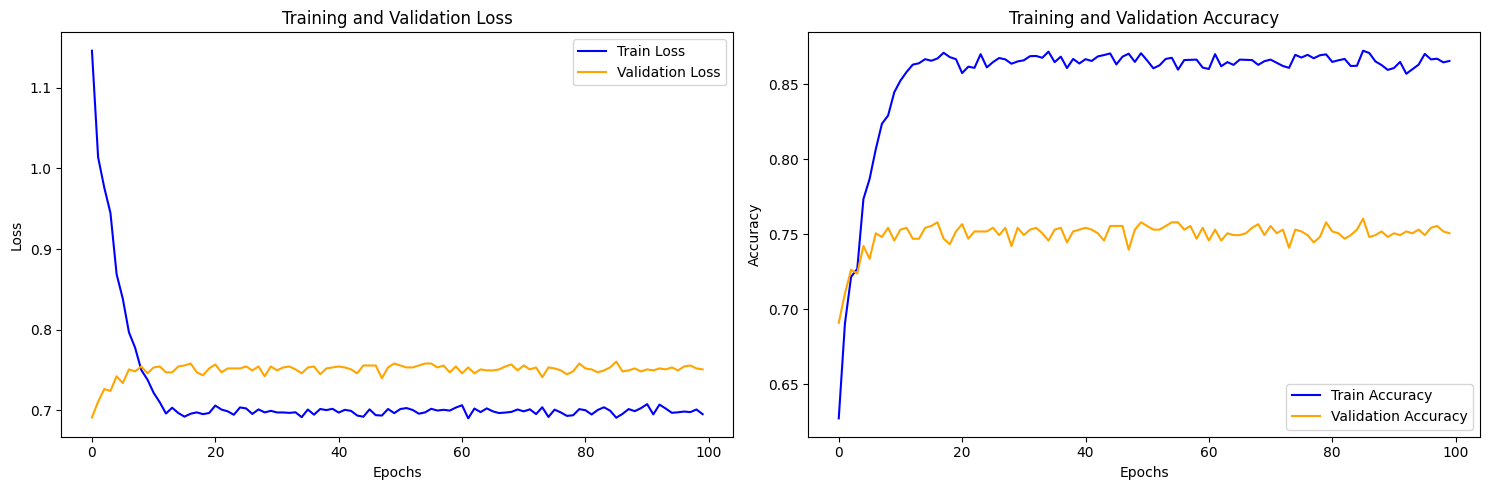

F1 Score: 0.7431
Accuracy: 0.7448
Report :
               precision    recall  f1-score   support

           0       0.83      0.85      0.84       207
           1       0.70      0.78      0.74       175
           2       0.72      0.58      0.64       113
           3       0.65      0.64      0.64       165
           4       0.80      0.80      0.80       163

    accuracy                           0.74       823
   macro avg       0.74      0.73      0.73       823
weighted avg       0.74      0.74      0.74       823



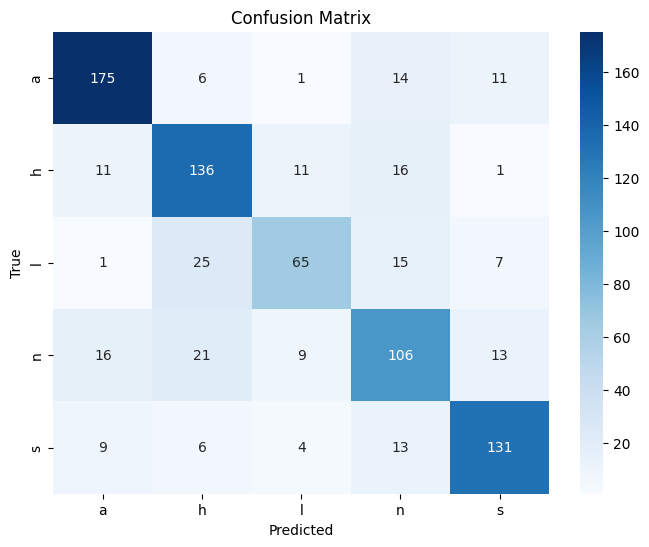

In [97]:
from sklearn.metrics import confusion_matrix, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting Loss and Accuracy
plot_metrics(train_losses, test_losses, train_accuracies, test_accuracies, validation_accuracies)

# Calculate F1 Score
model.eval()
all_predicted = []
all_targets = []

for batch in test_loader:
    # Unpack the batch
    speech_features, video_features, text_features, targets = batch

    # Move data to device
    speech_features, video_features, text_features, targets = (
        speech_features.to(device).float(),
        video_features.to(device).float(),
        text_features.to(device).float(),
        targets.to(device)
    )

    # Forward pass
    outputs = model(video_features, speech_features, text_features)
    _, predicted = torch.max(outputs, 1)

    all_predicted.extend(predicted.cpu().numpy())
    all_targets.extend(targets.cpu().numpy())

# Calculate accuracy
accuracy = sum([1 for i, j in zip(all_predicted, all_targets) if i == j]) / len(all_targets)

f1 = f1_score(all_targets, all_predicted, average='weighted')
print(f"F1 Score: {f1:.4f}")

# Classification Report
report = classification_report(all_targets, all_predicted)
print(f"Accuracy: {accuracy:.4f}")
print("Report :\n", report)

# Confusion Matrix
labels_list = label_encoder.classes_
conf_matrix = confusion_matrix(all_targets, all_predicted)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labels_list, yticklabels=labels_list)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()